<a href="https://colab.research.google.com/github/hassan1303/Vegetable_Image_Classification/blob/main/Vegetable_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ArewaDS Deep Learning Cohort 2.0 – Capstone Project  
### Project Title: Deep Learning-Based Vegetable Image Classification


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import numpy as np
import time
import copy
import random
import numpy as np
import os
from PIL import Image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
data_dir = "/content/drive/MyDrive/Vegetables_Classification_Project/Vegetable_Images"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "validation")
test_dir = os.path.join(data_dir, "test")

batch_size = 8

data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "validation": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "test": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
}

image_datasets = {
    "train": datasets.ImageFolder(train_dir, transform=data_transforms["train"]),
    "validation": datasets.ImageFolder(val_dir, transform=data_transforms["validation"]),
    "test": datasets.ImageFolder(test_dir, transform=data_transforms["test"])
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True, num_workers=2)
    for x in ["train", "validation", "test"]
}

class_names = image_datasets["train"].classes
print(class_names)

['Cabbage', 'Carrot', 'Cucumber', 'Tomato']


In [5]:
for inputs, labels in dataloaders["train"]:
    print("Loaded batch shape:", inputs.shape)
    break

Loaded batch shape: torch.Size([8, 3, 224, 224])


In [6]:
def visualize_imgs_from_dataset(image_folder_dataset, class_names, pts_per_class=3, color_scale=None):
    """
    Visualize sample images from an ImageFolder dataset.

    Parameters:
    - image_folder_dataset: dataset returned by torchvision.datasets.ImageFolder
    - class_names: list of class names
    - pts_per_class: number of images to show per class
    - color_scale: 'gray' or None (RGB)
    """
    # Create a dictionary to hold image paths per class
    class_to_images = {class_name: [] for class_name in class_names}

    for path, label in image_folder_dataset.samples:
        class_name = class_names[label]
        class_to_images[class_name].append(path)

    plt.rcParams["axes.grid"] = False

    for pt in range(pts_per_class):
        fig, axarr = plt.subplots(1, len(class_names), figsize=(15, 3))
        if len(class_names) == 1:
            axarr = [axarr]
        axarr[0].set_ylabel("Sample {}".format(pt + 1))

        for i, class_name in enumerate(class_names):
            img_path = random.choice(class_to_images[class_name])
            img = Image.open(img_path).resize((224, 224))

            if color_scale == 'gray':
                img = img.convert('L')
                axarr[i].imshow(img, cmap='gray')
            else:
                axarr[i].imshow(img)

            axarr[i].set_title(class_name)
            axarr[i].axis('off')

        plt.tight_layout()
        plt.show()


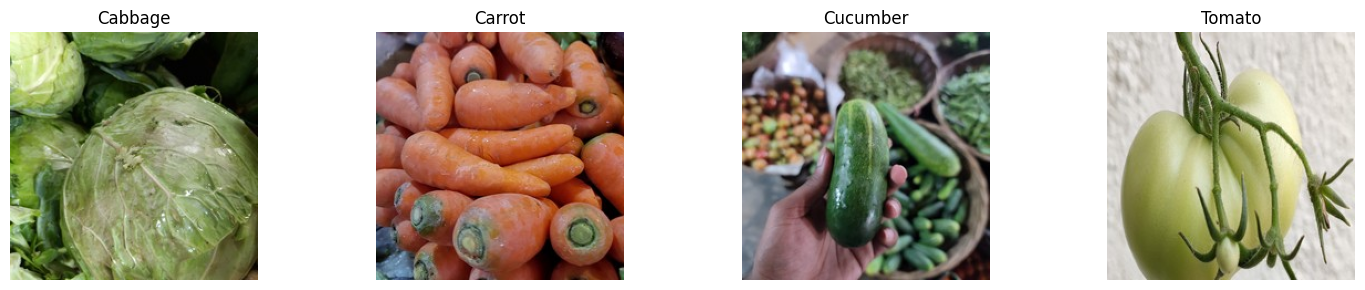

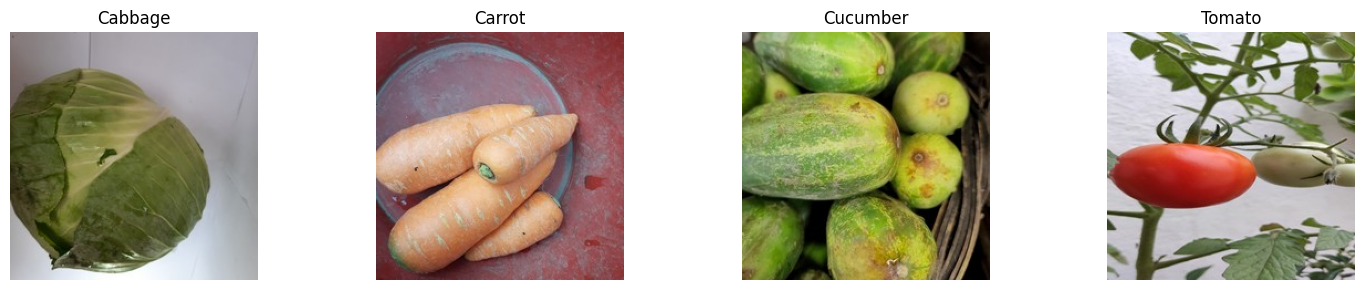

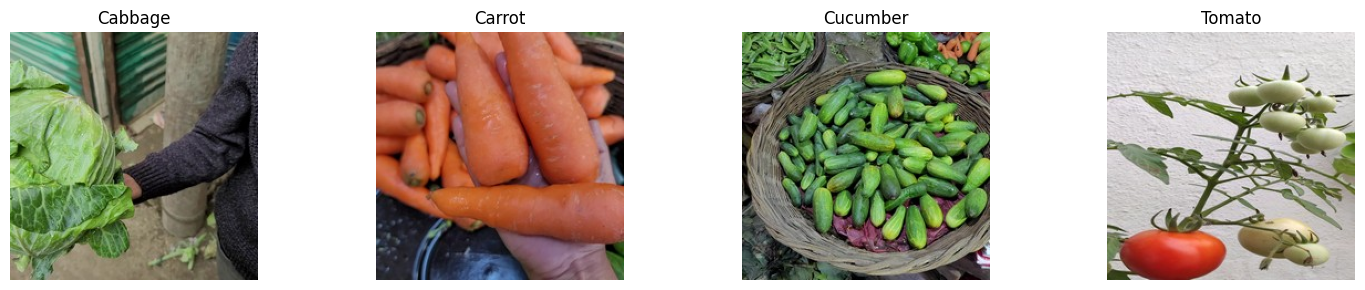

In [7]:
visualize_imgs_from_dataset(image_datasets["train"], class_names, pts_per_class=3, color_scale=None)

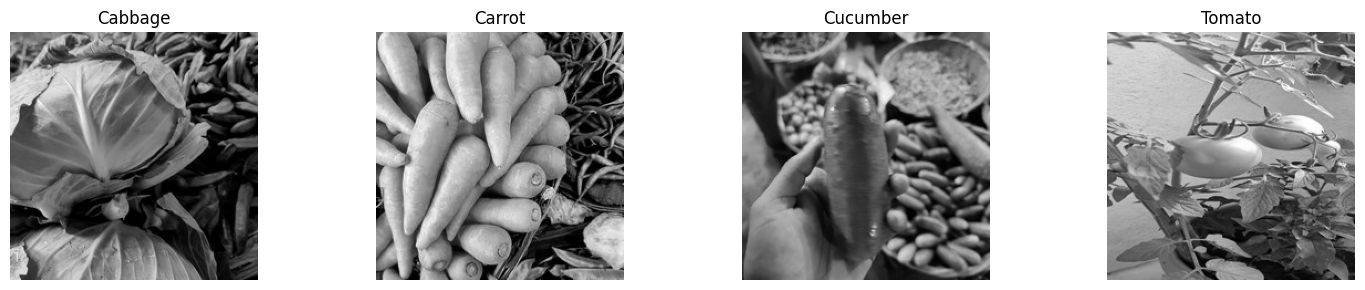

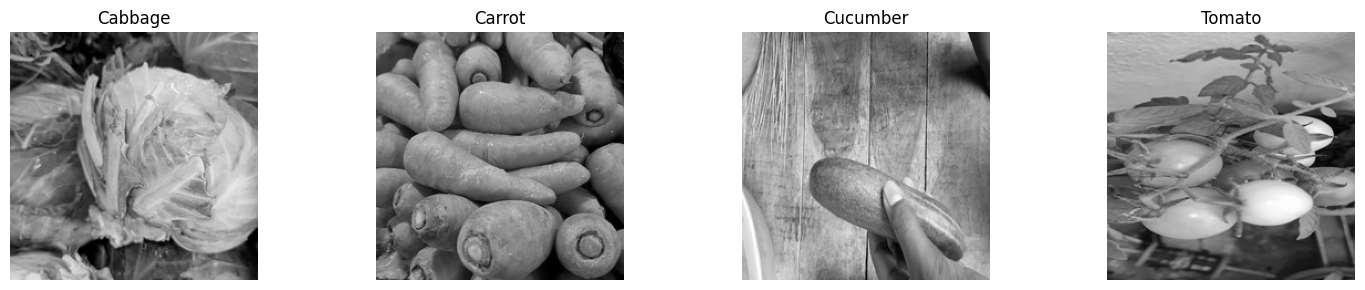

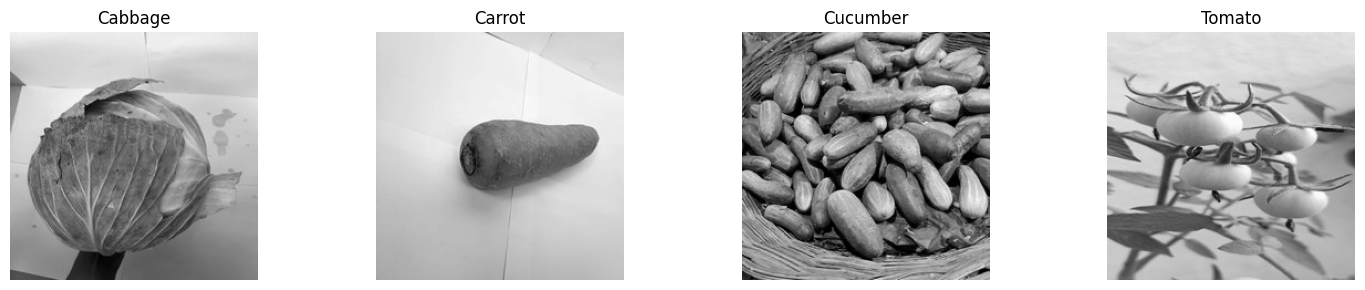

In [8]:
visualize_imgs_from_dataset(image_datasets["train"], class_names, pts_per_class=3, color_scale='gray')

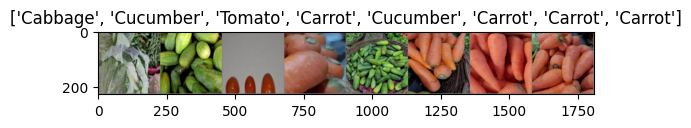

In [9]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = inp * 0.5 + 0.5
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.pause(0.001)

inputs, classes = next(iter(dataloaders["train"]))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[c] for c in classes])
